In [60]:
# Make vertical slice figure for MPAS

In [61]:
import numpy as np
import scipy
from netCDF4 import Dataset
from matplotlib import pyplot as plt
import xarray as xr
import matplotlib.colors as colors
import metpy
import cmaps
import matplotlib
from functions import *
from matplotlib.colors import ListedColormap, BoundaryNorm
import matplotlib.ticker as mticker

In [62]:
run_base = '/glade/derecho/scratch/cjablono/cam_6_4_161.MPAS.Lamb_wave.p_perturb/'

run_path1 = run_base + 'MPAS120.L100.top_50km.1.T275.smdiv_0.3D.nc'
run_path2 = run_base + 'MPAS120.L100.top_50km.1.T275.3D.nc'

nc1 = Dataset(run_path1, 'r')
nc2 = Dataset(run_path2, 'r')

In [63]:
time = nc1['time'][:]
lat = nc1['lat'][:]
lon = nc1['lon'][:]
lev = nc1['lev'][:]
ilev = nc1['ilev'][:]

print(len(lev))

#print(nc1.variables)

100


In [64]:
# Crop to the desired lon range if we want.

LON, LEV = np.meshgrid(lon, lev)
iLON, iLEV = np.meshgrid(lon, ilev)

# Examine at the equator
lat_val = 90

# Check this is the equator
print(lat[lat_val])

0.0


In [65]:
t_idx = 10

w1 = nc1['w_mpas'][t_idx, :, lat_val, :]
u1 = nc1['U'][t_idx, :, lat_val, :]
w2 = nc2['w_mpas'][t_idx, :, lat_val, :]
u2 = nc2['U'][t_idx, :, lat_val, :]

print(np.shape(w1))
print(np.shape(u1))
print(np.shape(w2))
print(np.shape(u2))

print(np.min(u1), np.max(u1))
print(np.min(u2), np.max(u2))

print(np.min(w1), np.max(w1))
print(np.min(w2), np.max(w2))

(101, 360)
(100, 360)
(101, 360)
(100, 360)
-2.541421 2.5364685
-1.2371609 1.2263848
-0.051798694 0.04912896
-0.01890678 0.017892074


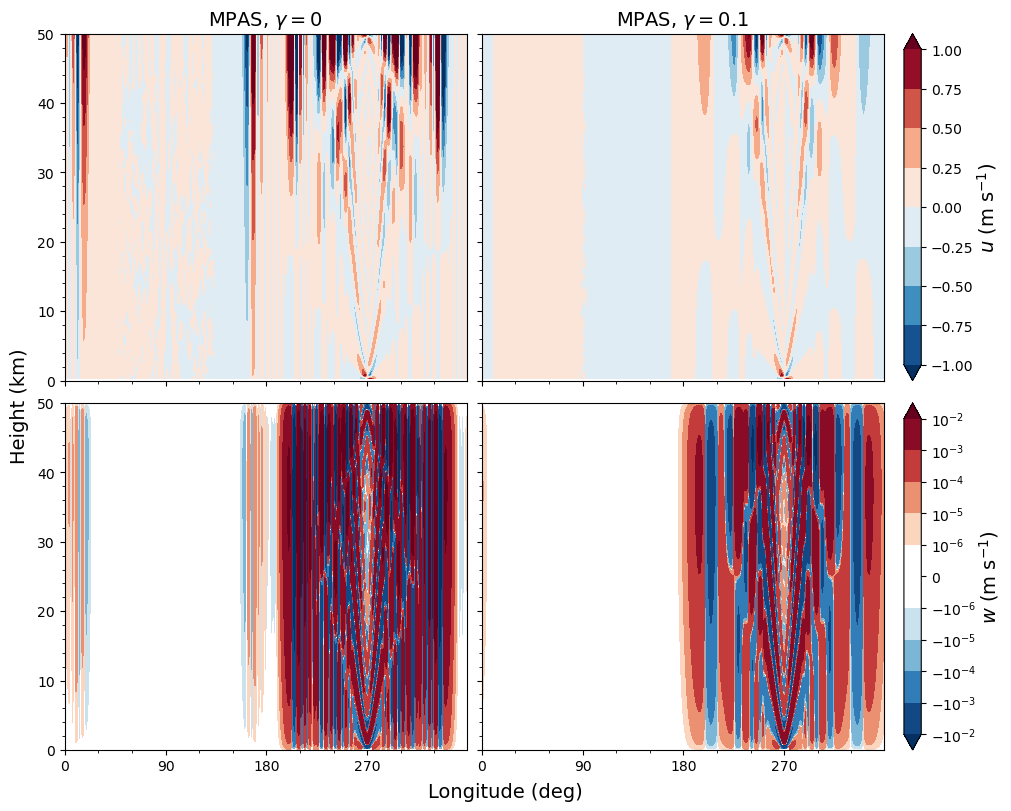

In [69]:
u_cmap = 'RdBu_r'

xticks = [0,90,180,270]

# Logarithmic magnitude bins, with two white bins next to zero
w_conts = np.array([
    -1e-2, -1e-3, -1e-4, -1e-5, -1e-6,
     0.0,
     1e-6,  1e-5,  1e-4,  1e-3,  1e-2
])

base = plt.colormaps["RdBu_r"]  # negative=blue, positive=red

# One color per interval: len(w_conts) - 1 = 10
w_colors = [
    base(0.05),  # -1e-2 to -1e-3: dark blue
    base(0.15),  # -1e-3 to -1e-4
    base(0.27),  # -1e-4 to -1e-5
    base(0.39),  # -1e-5 to -1e-6: pale blue
    "white",     # -1e-6 to 0
    "white",     # 0 to 1e-6
    base(0.61),  # 1e-6 to 1e-5: pale red
    base(0.73),  # 1e-5 to 1e-4
    base(0.85),  # 1e-4 to 1e-3
    base(0.95),  # 1e-3 to 1e-2: dark red
]

w_cmap = ListedColormap(w_colors, name="lamb_wave_RdBu")
w_cmap.set_under(base(0.0))
w_cmap.set_over(base(1.0))

# Do not pass extend="both" to BoundaryNorm
w_norm = BoundaryNorm(w_conts, ncolors=w_cmap.N)
fig, axes = plt.subplots(2,2, sharex=True, sharey=True, constrained_layout=True, figsize=(10,8))
(ax1,ax2), (ax3, ax4) = axes

u_conts = np.linspace(-1, 1, 9)

#w_conts = np.linspace(-0.1, 0.1, 10)
#w_conts = [-1e-2,-1e-3,-1e-4,-1e-5,-1e-6,0,1e-6, 1e-5,1e-4,1e-3,1e-2]

ax1.contourf(LON, LEV/1e3, u1, levels=u_conts, cmap = u_cmap, extend='both')
ax3.contourf(iLON, iLEV/1e3, w1, levels=w_conts, cmap = w_cmap, norm=w_norm, extend='both')
plot2 = ax2.contourf(LON, LEV/1e3, u2, levels=u_conts, cmap = u_cmap, extend='both')
plot4 = ax4.contourf(iLON, iLEV/1e3, w2, levels=w_conts, cmap = w_cmap, norm=w_norm, extend='both')

ax1.set_title(r'MPAS, $\gamma=0$', fontsize=14)
ax2.set_title(r'MPAS, $\gamma=0.1$', fontsize=14)
#ax3.set_title(r'$w$ $(\gamma=0)$', fontsize=14)
#ax4.set_title(r'$w$ $(\gamma=0.1)$', fontsize=14)

u_cbar = plt.colorbar(plot2, ticks=u_conts)
w_cbar = plt.colorbar(plot4, ticks=w_conts)

for ax in axes.flatten():
    ax.set_xticks(xticks)
    ax.xaxis.set_minor_locator(mticker.MultipleLocator(30))
    ax.yaxis.set_minor_locator(mticker.MultipleLocator(2))

fig.supylabel('Height (km)', size=14)
fig.supxlabel('Longitude (deg)', size=14)

formatter = mticker.ScalarFormatter(useMathText=True)
formatter.set_scientific(True)
formatter.set_powerlimits((0, 0))

w_cbar.set_ticks(w_conts)

w_cbar.set_ticklabels([
    r"$-10^{-2}$",
    r"$-10^{-3}$",
    r"$-10^{-4}$",
    r"$-10^{-5}$",
    r"$-10^{-6}$",
    r"$0$",
    r"$10^{-6}$",
    r"$10^{-5}$",
    r"$10^{-4}$",
    r"$10^{-3}$",
    r"$10^{-2}$",
])

u_cbar.ax.xaxis.set_major_formatter(formatter)
u_cbar.update_ticks()

u_cbar.set_label(
    r"$u$ (m s$^{-1}$)",
    fontsize=14,
    rotation=90,
    labelpad=18
)
u_cbar.ax.yaxis.set_label_position("right")
u_cbar.ax.yaxis.label.set_verticalalignment("bottom")

w_cbar.set_label(
    r"$w$ (m s$^{-1}$)",
    fontsize=14,
    rotation=90,
    labelpad=18
)
w_cbar.ax.yaxis.set_label_position("right")
w_cbar.ax.yaxis.label.set_verticalalignment("bottom")

plt.savefig(f'figures/mpas_vertical_slice.png',dpi=500, bbox_inches='tight')